In [10]:
# imports
from MarkovChain import MarkovChain
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import plotly.express as px

In [4]:
unstressed = MarkovChain("/Users/anu/Documents/carleton/fly_syntax_nlp/data/HeatData25C.csv")
stressed = MarkovChain("/Users/anu/Documents/carleton/fly_syntax_nlp/data/HeatData37C.csv")

['abdominal', 'back_leg_rubbing', 'front_leg_rubbing', 'head', 'stand', 'thorax', 'wing']
['abdominal', 'back_leg_rubbing', 'front_leg_rubbing', 'head', 'stand', 'thorax', 'wing']


/Users/anu/Documents/carleton/fly_syntax_nlp/MarkovChain.py:68: RuntimeWarning: invalid value encountered in divide
  probabilities = (frequencies.values)/normalizing
/Users/anu/Documents/carleton/fly_syntax_nlp/MarkovChain.py:68: RuntimeWarning: invalid value encountered in divide
  probabilities = (frequencies.values)/normalizing


Text(0.5, 1.0, 'Difference')

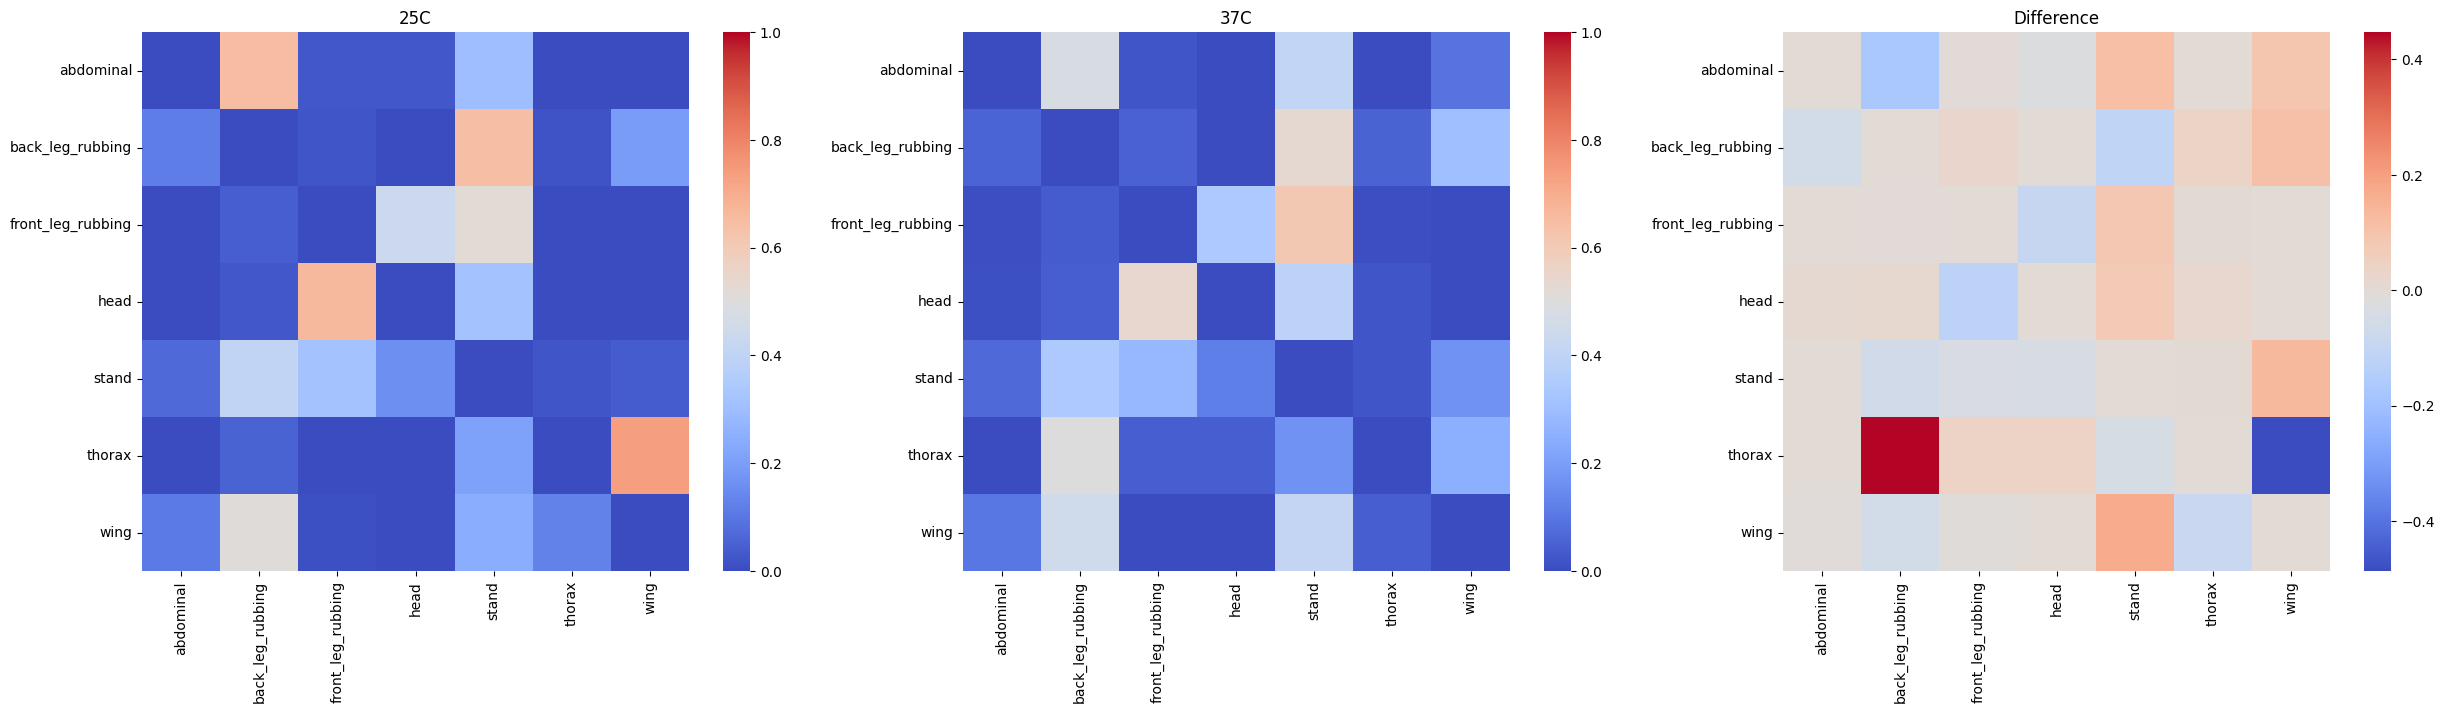

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(30, 7), sharex=True)

sns.heatmap(unstressed.mean_markovs_new(), ax = axes[0], vmin=0, vmax=1, cmap = "coolwarm")
axes[0].set_title('25C')

sns.heatmap(stressed.mean_markovs_new(), ax = axes[1], vmin=0, vmax=1, cmap = "coolwarm")
axes[1].set_title('37C')

sns.heatmap(stressed.mean_markovs_new() - unstressed.mean_markovs_new(), ax = axes[2], cmap = "coolwarm")
axes[2].set_title('Difference')

<Axes: xlabel='Entropy', ylabel='Density'>

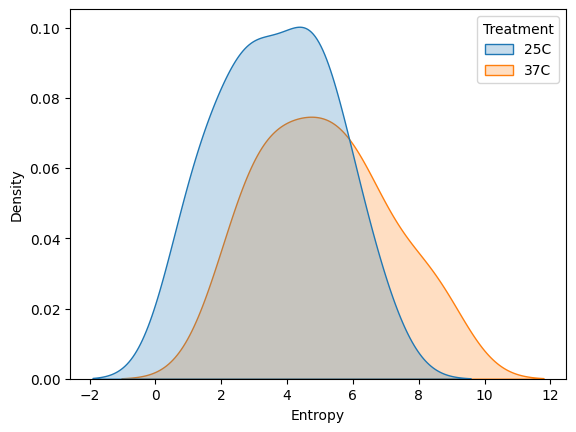

In [15]:
unstressed_list, unstressed_mu, unstressed_std = unstressed.get_entropy()
stressed_list, stressed_mu, stressed_std = stressed.get_entropy()

sns.kdeplot(pd.DataFrame({"Entropy": unstressed_list + stressed_list, "Treatment": ["25C"]*len(unstressed_list) + ["37C"]*len(stressed_list)}), x="Entropy", hue="Treatment", fill=True)


In [16]:
t_stat, p_value = stats.ttest_ind_from_stats(
    unstressed_mu, unstressed_std, 25, 
    stressed_mu, stressed_std, 20, 
    equal_var=False,
    alternative="less"
)

In [18]:
t_stat

np.float64(-2.672275418227178)

In [7]:
len(unstressed.probability_list), len(stressed.probability_list)

(25, 20)

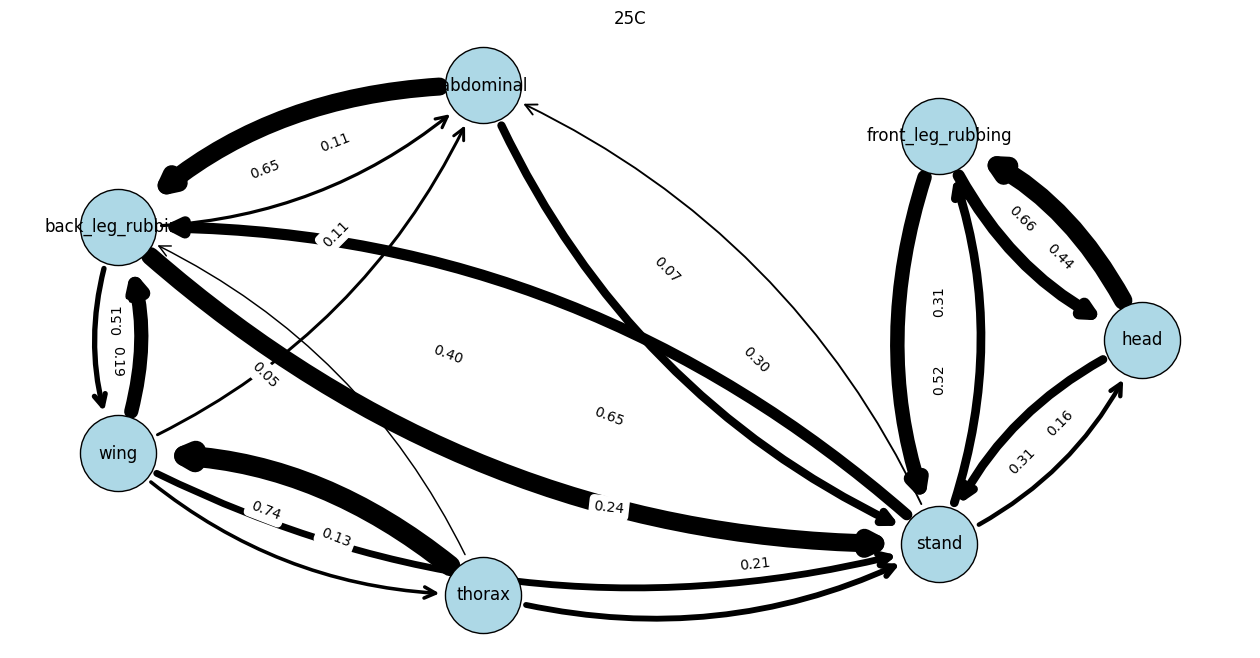

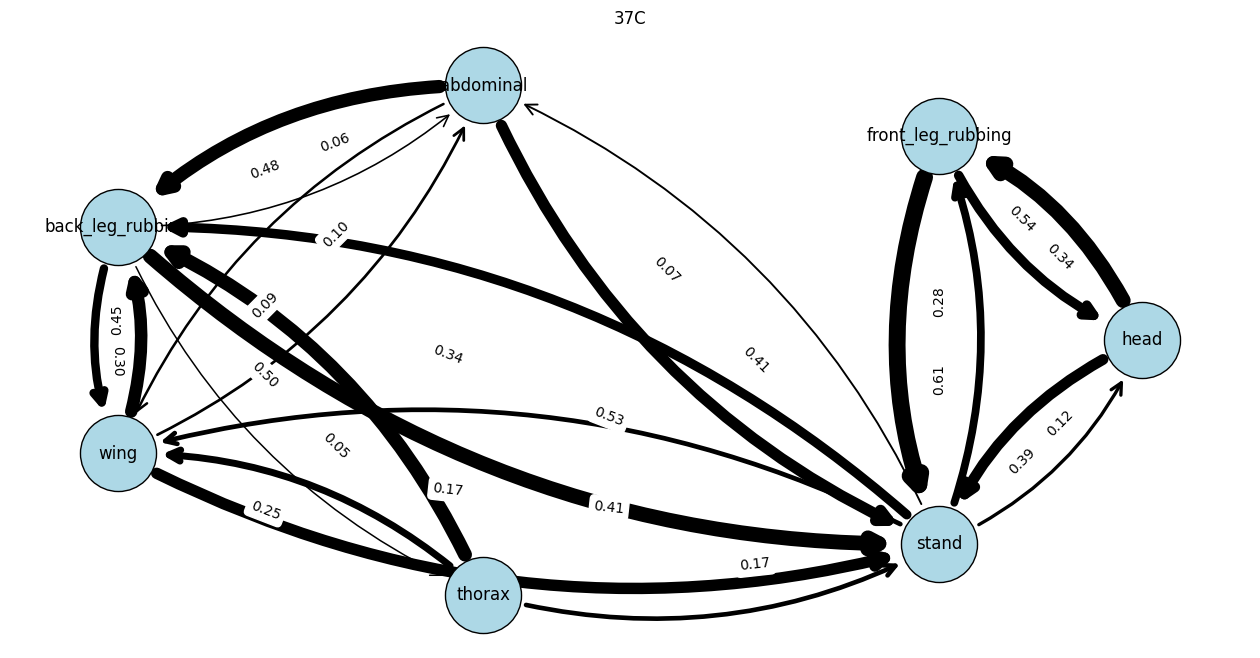

In [8]:
unstressed.show_markov_graph(title = "25C")
stressed.show_markov_graph(title = "37C")

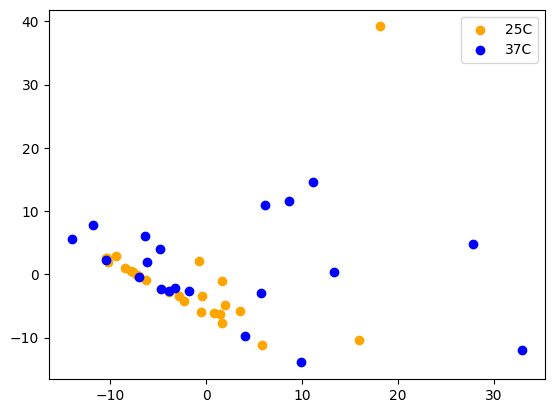

In [11]:
# embedder = TSNE(
#     n_components=2,
#     init="random",
#     max_iter=1000,
#     random_state=1,
# )

embedder = PCA(
    n_components=3
)
X = [np.reshape(df.values, 49) for df in unstressed.probability_list + stressed.probability_list]
X_f = [np.reshape(df.values, 49) for df in unstressed.frequency_list + stressed.frequency_list]

genotype = ["unstressed" for _ in unstressed.probability_list] + ["stressed" for _ in stressed.probability_list]

reduced_syntax = embedder.fit_transform(np.array(X_f))

plt.scatter(reduced_syntax[:25, 0], reduced_syntax[:25, 1], color="orange", label="25C")
plt.scatter(reduced_syntax[25:, 0], reduced_syntax[25:, 1], color="blue", label="37C")
plt.legend()

In [17]:
min([len(unstressed.df_list[i]) for i in range(len(unstressed.df_list))])

5